# Giai đoạn 1: EDA và Trực quan hóa

In [2]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", None)

DATA_DIR = Path("../data/raw")

employee_path = DATA_DIR / "Employee_Churn_Dataset.csv"
ibm_path = DATA_DIR / "IBM_HR_Analytics_Employee_Attrition_and_Performance.csv"

employee_df = pd.read_csv(employee_path)
ibm_df = pd.read_csv(ibm_path)

print("Loaded datasets:")
print(f"- Employee_Churn_Dataset: {employee_df.shape}")
print(f"- IBM_HR_Analytics_Employee_Attrition_and_Performance: {ibm_df.shape}")

Loaded datasets:
- Employee_Churn_Dataset: (10000, 22)
- IBM_HR_Analytics_Employee_Attrition_and_Performance: (1470, 35)


In [3]:
def quick_overview(df: pd.DataFrame, name: str, target_col: str = None):
    print(f"\n{'='*80}")
    print(f"{name} - Overview")
    print(f"{'='*80}")
    print("Shape:", df.shape)
    print("\nDtypes:")
    print(df.dtypes.value_counts())
    print("\nMissing values (top 10):")
    print(df.isna().sum().sort_values(ascending=False).head(10))
    if target_col and target_col in df.columns:
        print(f"\nTarget distribution ({target_col}):")
        print(df[target_col].value_counts(dropna=False))

quick_overview(employee_df, "Employee_Churn_Dataset", target_col="Churn")
quick_overview(ibm_df, "IBM_HR_Analytics_Employee_Attrition_and_Performance", target_col="Attrition")


Employee_Churn_Dataset - Overview
Shape: (10000, 22)

Dtypes:
int64      12
str         8
float64     2
Name: count, dtype: int64

Missing values (top 10):
Employee ID        0
Age                0
Gender             0
Education Level    0
Marital Status     0
Tenure             0
Job Role           0
Department         0
Salary             0
Work Location      0
dtype: int64

Target distribution (Churn):
Churn
0    7972
1    2028
Name: count, dtype: int64

IBM_HR_Analytics_Employee_Attrition_and_Performance - Overview
Shape: (1470, 35)

Dtypes:
int64    26
str       9
Name: count, dtype: int64

Missing values (top 10):
Age                 0
Attrition           0
BusinessTravel      0
DailyRate           0
Department          0
DistanceFromHome    0
Education           0
EducationField      0
EmployeeCount       0
EmployeeNumber      0
dtype: int64

Target distribution (Attrition):
Attrition
No     1233
Yes     237
Name: count, dtype: int64


### Nhận xét từ Overview (cả 2 dataset)

**Employee_Churn_Dataset:**
- Số mẫu: **10,000**, số cột: **22**.
- Target `Churn`: **0 = 7,972** và **1 = 2,028** (mất cân bằng vừa, tỷ lệ lớp 1 khoảng 20.28%).
- Không có missing đáng kể trong các cột chính.

**IBM_HR_Analytics_Employee_Attrition_and_Performance:**
- Số mẫu: **1,470**, số cột: **35**.
- Target `Attrition`: **No = 1,233** và **Yes = 237** (mất cân bằng rõ, tỷ lệ nghỉ việc khoảng 16.12%).
- Dữ liệu sạch ở mức cơ bản (không có missing trong các cột chính).

> **Kết luận:** Cả 2 bộ dữ liệu đều có hiện tượng **mất cân bằng nhãn**.
>
> **Hướng xử lý cho giai đoạn modeling:** dùng **SMOTE/GAN** (hoặc class weight) trên tập train để tránh mô hình thiên lệch về lớp đa số.

## Correlation Heatmap cho IBM Dataset

Heatmap bên dưới sử dụng các biến số của bộ IBM (bao gồm cả biến mục tiêu `Attrition` sau khi mã hóa `Yes/No -> 1/0`) để quan sát mức độ tương quan tuyến tính giữa các đặc trưng.

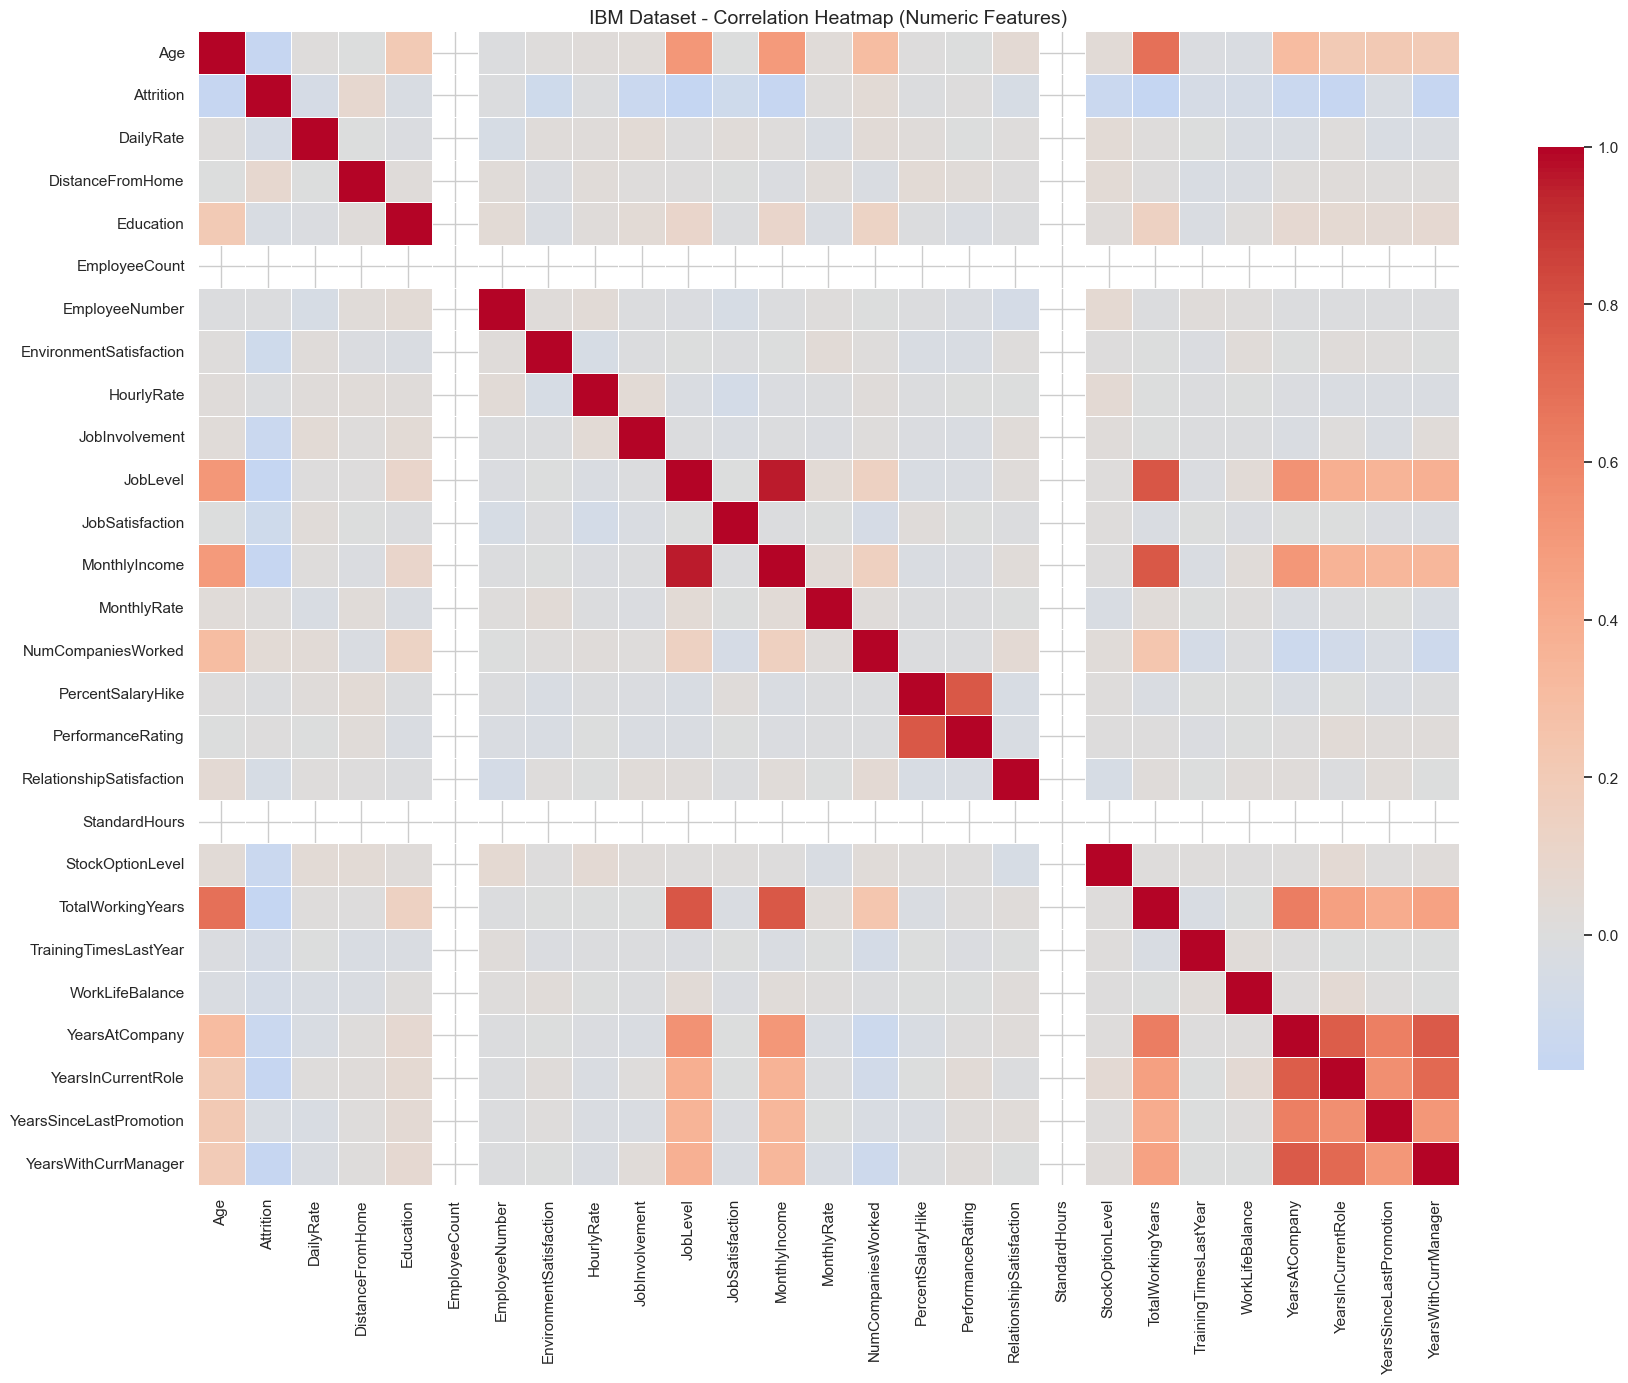

In [4]:
ibm_num = ibm_df.copy()
ibm_num["Attrition"] = ibm_num["Attrition"].map({"Yes": 1, "No": 0})

numeric_cols = ibm_num.select_dtypes(include=[np.number]).columns.tolist()
ibm_corr = ibm_num[numeric_cols].corr()

plt.figure(figsize=(18, 14))
sns.heatmap(
    ibm_corr,
    cmap="coolwarm",
    center=0,
    square=False,
    linewidths=0.4,
    cbar_kws={"shrink": 0.8}
)
plt.title("IBM Dataset - Correlation Heatmap (Numeric Features)", fontsize=14)
plt.tight_layout()
plt.show()

In [5]:
# Lấy các cặp biến có tương quan mạnh |r| > 0.4 (không lặp)
threshold = 0.4
corr_pairs = ibm_corr.where(np.triu(np.ones(ibm_corr.shape), k=1).astype(bool))
strong_pairs = (
    corr_pairs.stack()
    .reset_index()
    .rename(columns={"level_0": "Feature_1", "level_1": "Feature_2", 0: "Correlation"})
)
strong_pairs = strong_pairs[strong_pairs["Correlation"].abs() > threshold]
strong_pairs = strong_pairs.sort_values(by="Correlation", key=lambda s: s.abs(), ascending=False)

print(f"So cap co |r| > {threshold}: {len(strong_pairs)}")
strong_pairs.head(20)

So cap co |r| > 0.4: 19


,Feature_1,Feature_2,Correlation
282,JobLevel,MonthlyIncome,0.950300
290,JobLevel,TotalWorkingYears,0.782208
421,PercentSalaryHike,PerformanceRating,0.773550
344,MonthlyIncome,TotalWorkingYears,0.772893
647,YearsAtCompany,YearsWithCurrManager,0.769212
645,YearsAtCompany,YearsInCurrentRole,0.758754
674,YearsInCurrentRole,YearsWithCurrManager,0.714365
20,Age,TotalWorkingYears,0.680381
563,TotalWorkingYears,YearsAtCompany,0.628133
646,YearsAtCompany,YearsSinceLastPromotion,0.618409


### Nhận xét từ Heatmap và danh sách cặp tương quan mạnh

- Có **19 cặp** biến với $|r| > 0.4$.
- Các cặp nổi bật nhất:
  - `JobLevel` - `MonthlyIncome`: **0.9503** (rất mạnh)
  - `JobLevel` - `TotalWorkingYears`: **0.7822**
  - `MonthlyIncome` - `TotalWorkingYears`: **0.7729**
  - `PercentSalaryHike` - `PerformanceRating`: **0.7735**
- Nhóm biến thâm niên (`YearsAtCompany`, `YearsInCurrentRole`, `YearsWithCurrManager`, `YearsSinceLastPromotion`) có tương quan chéo cao.

> **Ý nghĩa thực hành:** khi xây dựng mô hình tuyến tính/logistic, cần lưu ý **đa cộng tuyến** trong nhóm biến thu nhập-cấp bậc-thâm niên.

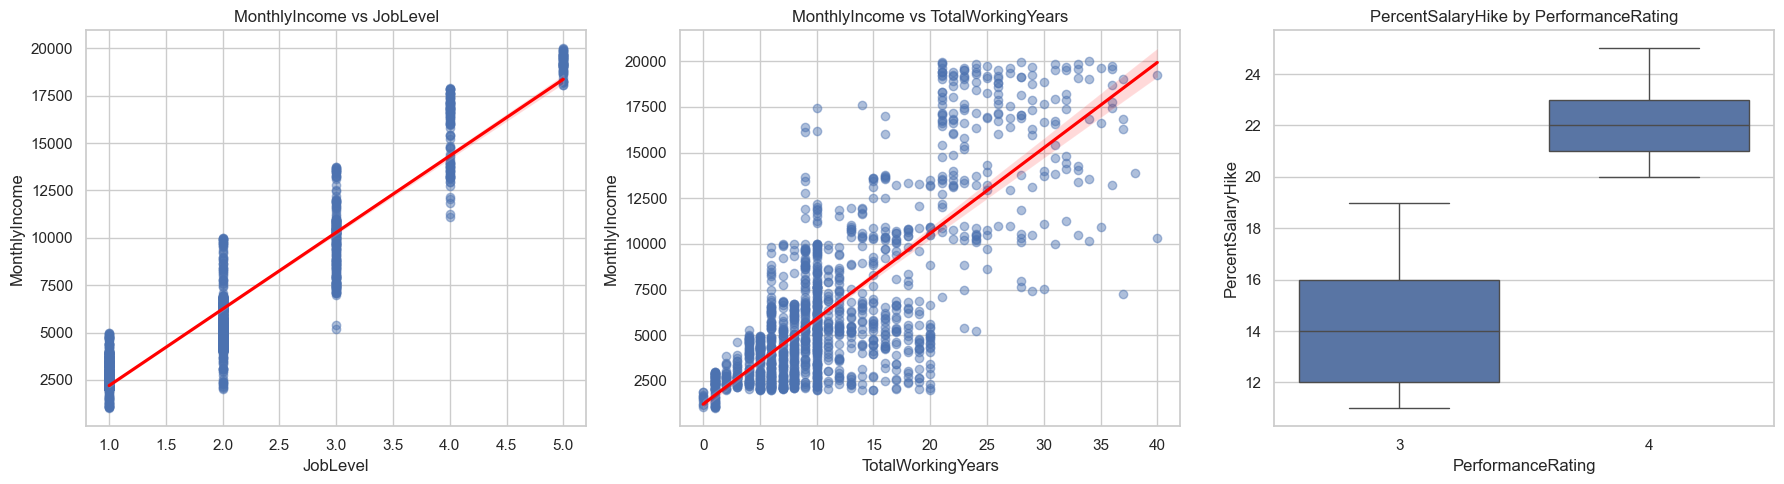


Tuong quan cua cac bien trong nhom voi Attrition:


,Corr_with_Attrition
TotalWorkingYears,-0.171063
JobLevel,-0.169105
MonthlyIncome,-0.159840
PercentSalaryHike,-0.013478
PerformanceRating,0.002889


In [7]:
# Trực quan các cặp biến chính + tương quan với Attrition
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.regplot(data=ibm_num, x="JobLevel", y="MonthlyIncome", scatter_kws={"alpha": 0.45}, line_kws={"color": "red"}, ax=axes[0])
axes[0].set_title("MonthlyIncome vs JobLevel")

sns.regplot(data=ibm_num, x="TotalWorkingYears", y="MonthlyIncome", scatter_kws={"alpha": 0.45}, line_kws={"color": "red"}, ax=axes[1])
axes[1].set_title("MonthlyIncome vs TotalWorkingYears")

sns.boxplot(data=ibm_num, x="PerformanceRating", y="PercentSalaryHike", ax=axes[2])
axes[2].set_title("PercentSalaryHike by PerformanceRating")

plt.tight_layout()
plt.show()

focus_vars = ["MonthlyIncome", "JobLevel", "TotalWorkingYears", "PerformanceRating", "PercentSalaryHike"]
attr_corr = ibm_corr.loc[focus_vars, "Attrition"].sort_values(key=lambda s: s.abs(), ascending=False)

print("\nTuong quan cua cac bien trong nhom voi Attrition:")
display(attr_corr.to_frame(name="Corr_with_Attrition"))

### Nhận xét từ biểu đồ cặp biến chính

- `MonthlyIncome` tăng rõ theo `JobLevel` và `TotalWorkingYears` (phù hợp với hệ số tương quan mạnh).
- `PercentSalaryHike` phân tách khá rõ theo `PerformanceRating` (nhóm rating cao nhận hike cao hơn).
- Tuy vậy, tương quan trực tiếp của nhóm biến này với `Attrition` chỉ ở mức yếu đến vừa:
  - `TotalWorkingYears`: -0.1711
  - `JobLevel`: -0.1691
  - `MonthlyIncome`: -0.1598
  - `PercentSalaryHike`: -0.0135
  - `PerformanceRating`: 0.0029

> **Hàm ý:** các biến này hữu ích, nhưng chưa đủ để giải thích nghỉ việc nếu đứng riêng; nên kết hợp thêm nhóm biến hài lòng, overtime, work-life balance và quan hệ quản lý.

## Kết luận nhanh cho Giai đoạn 1

Từ heatmap và các phép đo tương quan trên IBM dataset:

- Cặp tương quan mạnh nhất trong nhóm thu nhập/cấp bậc/kinh nghiệm:
  - `MonthlyIncome` - `JobLevel`: tương quan rất mạnh, dương.
  - `MonthlyIncome` - `TotalWorkingYears`: tương quan mạnh, dương.
- Các biến liên quan thâm niên (`YearsAtCompany`, `YearsInCurrentRole`, `YearsWithCurrManager`, `YearsSinceLastPromotion`) cũng có tương quan chéo cao.
- Mối liên hệ tuyến tính trực tiếp của nhóm biến trên với `Attrition` ở mức yếu đến trung bình (âm nhẹ với `MonthlyIncome`, `JobLevel`, `TotalWorkingYears`).

Hàm ý: các biến này quan trọng để đưa vào mô hình dự báo nghỉ việc, đồng thời cần kết hợp thêm các biến hành vi/hài lòng để tăng khả năng giải thích cho `Attrition`.

## Giai đoạn 2: Làm sạch dữ liệu và Loại bỏ đặc trưng
- Xử lý giá trị thiếu cho Kaggle dataset theo các cột chỉ định.
- Loại bỏ các cột không hữu ích/không biến thiên trong IBM dataset.
- Ghi nhận số lượng bản ghi/cột thay đổi sau làm sạch.

In [3]:
def find_first_existing(col_candidates, columns):
    for c in col_candidates:
        if c in columns:
            return c
    return None

# Tao ban sao de xu ly giai doan 2
kaggle_stage2 = employee_df.copy()
ibm_stage2 = ibm_df.copy()

# 1) Kaggle: xu ly missing theo cot yeu cau trong tai lieu (linh hoat theo ten cot thuc te)
kaggle_missing_aliases = {
    "Last-Evaluation": ["Last-Evaluation", "LastEvaluation", "Last Evaluation", "last_evaluation", "last_evaluation_score"],
    "Satisfaction": ["Satisfaction", "Satisfaction Level", "satisfaction", "satisfaction_level"],
    "Department": ["Department", "department"],
    "Tenure": ["Tenure", "tenure"],
}

kaggle_resolved_missing_cols = {
    spec: find_first_existing(cands, kaggle_stage2.columns)
    for spec, cands in kaggle_missing_aliases.items()
}

kaggle_subset_for_dropna = [c for c in kaggle_resolved_missing_cols.values() if c is not None]
kaggle_before_rows = len(kaggle_stage2)

if kaggle_subset_for_dropna:
    kaggle_stage2 = kaggle_stage2.dropna(subset=kaggle_subset_for_dropna).copy()

kaggle_after_rows = len(kaggle_stage2)
kaggle_removed_rows = kaggle_before_rows - kaggle_after_rows

# 2) IBM: loai bo cot khong huu ich
ibm_drop_candidates = ["EmployeeCount", "Over18", "StandardHours", "EmployeeNumber"]
ibm_drop_cols = [c for c in ibm_drop_candidates if c in ibm_stage2.columns]
ibm_stage2 = ibm_stage2.drop(columns=ibm_drop_cols).copy()

print("=== STAGE 2 REPORT ===")
print("Kaggle/Employee dataset:")
print("- Resolved columns for missing-value handling:")
for spec, real in kaggle_resolved_missing_cols.items():
    print(f"  - {spec}: {real if real is not None else 'NOT FOUND'}")
print(f"- Rows before: {kaggle_before_rows}")
print(f"- Rows after : {kaggle_after_rows}")
print(f"- Rows removed due to missing: {kaggle_removed_rows}")

print("\nIBM dataset:")
print(f"- Dropped columns: {ibm_drop_cols}")
print(f"- Shape after feature exclusion: {ibm_stage2.shape}")

=== STAGE 2 REPORT ===
Kaggle/Employee dataset:
- Resolved columns for missing-value handling:
  - Last-Evaluation: NOT FOUND
  - Satisfaction: Satisfaction Level
  - Department: Department
  - Tenure: Tenure
- Rows before: 10000
- Rows after : 10000
- Rows removed due to missing: 0

IBM dataset:
- Dropped columns: ['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber']
- Shape after feature exclusion: (1470, 31)


## Giai đoạn 3: Mã hóa dữ liệu (Data Encoding)
- Chuyển các biến phân loại sang dạng số để mô hình ML/DL có thể sử dụng.
- Ưu tiên mapping theo quy tắc trong tài liệu; nếu tên cột khác, tự động dò tên gần đúng.
- In ra nhận xét ngắn gọn từ kết quả mã hóa.

In [4]:
# Tao ban sao cho giai doan 3
ibm_stage3 = ibm_stage2.copy()
kaggle_stage3 = kaggle_stage2.copy()

# ---------------- IBM ENCODING ----------------
# Mapping theo tai lieu
if "BusinessTravel" in ibm_stage3.columns:
    ibm_stage3["BusinessTravel"] = ibm_stage3["BusinessTravel"].map({
        "Non-Travel": 0,
        "Travel_Rarely": 1,
        "Travel_Frequently": 2,
    })

if "Gender" in ibm_stage3.columns:
    ibm_stage3["Gender"] = ibm_stage3["Gender"].map({"Female": 0, "Male": 1})

if "OverTime" in ibm_stage3.columns:
    ibm_stage3["OverTime"] = ibm_stage3["OverTime"].map({"No": 0, "Yes": 1})

# Target IBM (phuc vu modeling): xu ly ca object/string/category
if "Attrition" in ibm_stage3.columns:
    if not pd.api.types.is_numeric_dtype(ibm_stage3["Attrition"]):
        ibm_stage3["Attrition"] = (
            ibm_stage3["Attrition"]
            .astype(str)
            .str.strip()
            .map({"No": 0, "Yes": 1})
        )

# One-hot cho bien danh muc nomial
ibm_nominal_cols = [c for c in ["Department", "EducationField", "JobRole", "MaritalStatus"] if c in ibm_stage3.columns]
ibm_stage3 = pd.get_dummies(ibm_stage3, columns=ibm_nominal_cols, drop_first=True)

# ---------------- KAGGLE/EMPLOYEE ENCODING ----------------
def resolve_col(columns, aliases):
    return find_first_existing(aliases, columns)

dept_col = resolve_col(kaggle_stage3.columns, ["Department", "department"])
salary_level_col = resolve_col(kaggle_stage3.columns, ["Salary Level", "salary_level", "SalaryLevel"])
target_col = resolve_col(kaggle_stage3.columns, ["Status", "status", "Churn"])  # Churn la truong hop dataset hien tai

# Target: 0 = dang lam, 1 = da nghi (hoac giu nguyen neu da la 0/1)
if target_col is not None:
    if not pd.api.types.is_numeric_dtype(kaggle_stage3[target_col]):
        target_map = {
            "Working": 0,
            "Active": 0,
            "Stayed": 0,
            "No": 0,
            "Left": 1,
            "Resigned": 1,
            "Yes": 1,
        }
        kaggle_stage3[target_col] = (
            kaggle_stage3[target_col]
            .astype(str)
            .str.strip()
            .map(target_map)
        )

# Department: one-hot
if dept_col is not None:
    kaggle_stage3 = pd.get_dummies(kaggle_stage3, columns=[dept_col], drop_first=True)

# Salary Level: chi encode neu la danh muc
salary_level_encoded = False
if salary_level_col is not None and salary_level_col in kaggle_stage3.columns:
    if kaggle_stage3[salary_level_col].dtype == "object" or kaggle_stage3[salary_level_col].nunique() <= 10:
        kaggle_stage3 = pd.get_dummies(kaggle_stage3, columns=[salary_level_col], drop_first=True)
        salary_level_encoded = True

# Cac cot object con lai: tu dong one-hot (tru cot ID)
id_like_cols = [c for c in kaggle_stage3.columns if "id" in c.lower()]
kaggle_object_cols = [
    c for c in kaggle_stage3.select_dtypes(include=["object", "string"]).columns
    if c not in id_like_cols
]
if kaggle_object_cols:
    kaggle_stage3 = pd.get_dummies(kaggle_stage3, columns=kaggle_object_cols, drop_first=True)

print("=== STAGE 3 REPORT ===")
print("IBM encoding:")
print(f"- Shape after encoding: {ibm_stage3.shape}")
print(f"- Attrition encoded to numeric: {'Attrition' in ibm_stage3.columns and pd.api.types.is_numeric_dtype(ibm_stage3['Attrition'])}")
print(f"- One-hot columns added from: {ibm_nominal_cols}")

print("\nKaggle/Employee encoding:")
print(f"- Resolved target column : {target_col}")
print(f"- Resolved department col: {dept_col}")
print(f"- Resolved salary level  : {salary_level_col}")
print(f"- Salary level encoded   : {salary_level_encoded}")
print(f"- Shape after encoding   : {kaggle_stage3.shape}")
print(f"- Remaining object cols  : {kaggle_stage3.select_dtypes(include=['object', 'string']).columns.tolist()}")

=== STAGE 3 REPORT ===
IBM encoding:
- Shape after encoding: (1470, 44)
- Attrition encoded to numeric: True
- One-hot columns added from: ['Department', 'EducationField', 'JobRole', 'MaritalStatus']

Kaggle/Employee encoding:
- Resolved target column : Churn
- Resolved department col: Department
- Resolved salary level  : None
- Salary level encoded   : False
- Shape after encoding   : (10000, 33)
- Remaining object cols  : ['Employee ID']


### Nhận xét từ kết quả Giai đoạn 2 và 3

**Giai đoạn 2 - Làm sạch và loại đặc trưng:**
- Sau khi xử lý missing trên các cột tìm thấy (`Satisfaction Level`, `Department`, `Tenure`), số dòng bị loại là **0** (10,000 -> 10,000).
- Với IBM dataset, đã loại đúng các cột không hữu ích: `EmployeeCount`, `Over18`, `StandardHours`, `EmployeeNumber`.
- Kích thước IBM sau loại đặc trưng: **(1470, 31)**.

**Giai đoạn 3 - Mã hóa dữ liệu:**
- IBM:
  - Đã mã hóa `BusinessTravel`, `Gender`, `OverTime`.
  - Đã chuyển `Attrition` sang nhị phân số (0/1).
  - Đã one-hot cho `Department`, `EducationField`, `JobRole`, `MaritalStatus`.
  - Kích thước sau mã hóa: **(1470, 44)**.
- Kaggle/Employee:
  - Mục tiêu được nhận diện là `Churn` (đã ở dạng số).
  - Đã one-hot cho `Department`.
  - Sau mã hóa vẫn còn `Employee ID` dạng chuỗi (đây là cột định danh, nên loại bỏ trước khi huấn luyện).
  - Kích thước sau mã hóa: **(10000, 33)**.

> **Kết luận quan trọng:** Dataset đang dùng không trùng hoàn toàn với schema mô tả trong bài báo khoa học (đặc biệt ở Kaggle), nên số bản ghi loại bỏ không ra mốc 1,532 như bài báo.

## Giai đoạn 4: Chuẩn hóa dữ liệu (Data Normalization)
- Đưa các đặc trưng số về cùng thang đo [0, 1] bằng Min-Max Scaling.
- Tránh hiện tượng biến có độ lớn lớn hơn lấn át quá trình học.
- Chỉ chuẩn hóa **feature đầu vào**; không chuẩn hóa cột mục tiêu và cột định danh.

In [5]:
from sklearn.preprocessing import MinMaxScaler

def minmax_normalize(df: pd.DataFrame, target_col: str = None, id_cols: list = None):
    id_cols = id_cols or []
    normalized_df = df.copy()

    exclude_cols = set(id_cols)
    if target_col is not None and target_col in normalized_df.columns:
        exclude_cols.add(target_col)

    numeric_feature_cols = [
        c for c in normalized_df.columns
        if c not in exclude_cols and pd.api.types.is_numeric_dtype(normalized_df[c])
    ]

    scaler = MinMaxScaler()
    if numeric_feature_cols:
        normalized_df[numeric_feature_cols] = scaler.fit_transform(normalized_df[numeric_feature_cols])

    return normalized_df, numeric_feature_cols

# IBM: target la Attrition, khong co ID sau stage 2
ibm_stage4, ibm_scaled_cols = minmax_normalize(
    ibm_stage3,
    target_col="Attrition",
    id_cols=[]
)

# Kaggle/Employee: target la Churn, giu Employee ID de theo doi (khong scale)
kaggle_stage4, kaggle_scaled_cols = minmax_normalize(
    kaggle_stage3,
    target_col="Churn",
    id_cols=["Employee ID"] if "Employee ID" in kaggle_stage3.columns else []
)

print("=== STAGE 4 REPORT ===")
print("IBM normalized:")
print(f"- Scaled feature count: {len(ibm_scaled_cols)}")
print(f"- Target excluded: {'Attrition' in ibm_stage4.columns}")
print(f"- Example scaled cols (first 10): {ibm_scaled_cols[:10]}")

print("\nKaggle/Employee normalized:")
print(f"- Scaled feature count: {len(kaggle_scaled_cols)}")
print(f"- Target excluded: {'Churn' in kaggle_stage4.columns}")
print(f"- ID excluded from scaling: {'Employee ID' in kaggle_stage4.columns}")
print(f"- Example scaled cols (first 10): {kaggle_scaled_cols[:10]}")

# Kiem tra nhanh min/max sau scale
if ibm_scaled_cols:
    ibm_min, ibm_max = ibm_stage4[ibm_scaled_cols].min().min(), ibm_stage4[ibm_scaled_cols].max().max()
    print(f"\nIBM global min/max after scaling: {ibm_min:.4f} / {ibm_max:.4f}")

if kaggle_scaled_cols:
    kaggle_min, kaggle_max = kaggle_stage4[kaggle_scaled_cols].min().min(), kaggle_stage4[kaggle_scaled_cols].max().max()
    print(f"Kaggle global min/max after scaling: {kaggle_min:.4f} / {kaggle_max:.4f}")

=== STAGE 4 REPORT ===
IBM normalized:
- Scaled feature count: 43
- Target excluded: True
- Example scaled cols (first 10): ['Age', 'BusinessTravel', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel']

Kaggle/Employee normalized:
- Scaled feature count: 31
- Target excluded: True
- ID excluded from scaling: True
- Example scaled cols (first 10): ['Age', 'Tenure', 'Salary', 'Performance Rating', 'Projects Completed', 'Training Hours', 'Promotions', 'Overtime Hours', 'Satisfaction Level', 'Average Monthly Hours Worked']

IBM global min/max after scaling: 0.0000 / 1.0000
Kaggle global min/max after scaling: 0.0000 / 1.0000


### Nhận xét từ kết quả Giai đoạn 4

- Min-Max Scaling đã được áp dụng thành công cho cả 2 dataset.
- IBM: chuẩn hóa **43** đặc trưng đầu vào; `Attrition` được giữ nguyên làm target.
- Kaggle/Employee: chuẩn hóa **31** đặc trưng đầu vào; `Churn` và `Employee ID` được loại khỏi chuẩn hóa.
- Kiểm tra toàn cục sau chuẩn hóa:
  - IBM: min/max = **0.0000 / 1.0000**
  - Kaggle/Employee: min/max = **0.0000 / 1.0000**

> **Kết luận:** Bước chuẩn hóa đã đạt đúng mục tiêu kỹ thuật và sẵn sàng cho giai đoạn huấn luyện mô hình (baseline + Bi-TCN).

## Giai đoạn 5: Xuất dữ liệu đã xử lý

Mục tiêu:
- Xuất các phiên bản dữ liệu sau từng bước xử lý vào thư mục data/processed.
- Đảm bảo có thể tái sử dụng trực tiếp cho huấn luyện và đánh giá mô hình.

In [6]:
PROCESSED_DIR = Path("../data/processed")
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

# Dam bao bo cot dinh danh truoc khi dua sang notebook huan luyen
kaggle_train_ready = kaggle_stage4.drop(columns=["Employee ID"], errors="ignore").copy()
ibm_train_ready = ibm_stage4.copy()

# Xuat duy nhat 2 file processed (train-ready)
final_export_map = {
    "Kaggle_Cleaned.csv": kaggle_train_ready,
    "IBM_Cleaned.csv": ibm_train_ready,
}

for file_name, df_out in final_export_map.items():
    out_path = PROCESSED_DIR / file_name
    df_out.to_csv(out_path, index=False, encoding="utf-8")

print("=== STAGE 5 REPORT (UPDATED) ===")
print(f"Output directory: {PROCESSED_DIR.resolve()}")
print("Exported files (train-ready):")
for file_name, df_out in final_export_map.items():
    print(f"- {file_name}: {df_out.shape}")

# Kiem tra an toan: feature khong con object/string
kaggle_non_numeric = kaggle_train_ready.drop(columns=["Churn"], errors="ignore").select_dtypes(include=["object", "string"]).columns.tolist()
ibm_non_numeric = ibm_train_ready.drop(columns=["Attrition"], errors="ignore").select_dtypes(include=["object", "string"]).columns.tolist()

print("\nSafety checks before training notebook:")
print(f"- Kaggle non-numeric feature cols: {kaggle_non_numeric}")
print(f"- IBM non-numeric feature cols: {ibm_non_numeric}")

=== STAGE 5 REPORT (UPDATED) ===
Output directory: F:\ML - DL Projects\Deep Learning Employee Attrition BiTCN\data\processed
Exported files (train-ready):
- Kaggle_Cleaned.csv: (10000, 32)
- IBM_Cleaned.csv: (1470, 44)

Safety checks before training notebook:
- Kaggle non-numeric feature cols: []
- IBM non-numeric feature cols: []
